# The concurrency envelope

This notebook derives the paper's Tables II and III and the generic-load
result from the raw benchmark logs in `docs/paper/artifacts/`. The
windowing rule (a concurrent flood run counts only if it starts and
finishes inside the decode window) lives in
`pi/flood/analyze_conc_bench.py`; the notebook calls that script rather
than reimplementing it.

In [1]:
import re, statistics, subprocess, sys
from pathlib import Path

ART = Path("../docs/paper/artifacts")
def analyze(d, steps=4000):
    out = subprocess.run([sys.executable, "../pi/flood/analyze_conc_bench.py", str(d), str(steps)],
                         capture_output=True, text=True)
    print(out.stdout)

analyze(ART / "conc_bench2")

flood opt alone                              2127.3 ±   1.7 steps/s  (n=3)
flood orig alone                             1348.9 ±   0.3 steps/s  (n=3)
flood opt under CPU decode                    711.9 ±  76.1 steps/s  (n=5)
flood orig under CPU decode                   340.1 ±  16.9 steps/s  (n=2)
llama alone                                    11.5 ±   0.0 t/s     (n=5)
llama vs opt                                   10.3 ±   0.2 t/s     (n=5)
llama vs orig                                  10.2 ±   0.3 t/s     (n=5)
route_alone                                    0.02 s
route_conc                                     0.02 s

thermal validity (max temp / samples with throttle ACTIVE):
  thermal_end.log                    max  68.1 C  VALID
  thermal_llama_alone.log            max  73.0 C  TAINTED (1 throttled samples)
  thermal_opt_conc.log               max  74.7 C  TAINTED (16 throttled samples)
  thermal_orig_conc.log              max  74.7 C  TAINTED (16 throttled samples)
  thermal_s

Those are the five rows of Table II, plus the router (which does not
move) and the per-phase thermal validity: sustained phases throttle
briefly on this passively cooled board, so the sustained numbers are
steady-state, thermally governed figures.

In [2]:
analyze(ART / "cpu_flood_bench2")

flood cpu1t alone                             992.0 ±   0.9 steps/s  (n=3)
flood cpu2t alone                            1977.9 ±   1.1 steps/s  (n=3)
flood cpu4t alone                            3803.2 ±  73.2 steps/s  (n=3)
flood cpu1part under CPU decode               680.6 ±  22.9 steps/s  (n=6)
flood cpu4over under CPU decode               703.4 ± 338.7 steps/s  (n=21)
llama alone                                    11.4 ±   0.1 t/s     (n=5)
llama t3 alone                                 11.8 ±   0.0 t/s     (n=5)
llama vs cpu1part                               8.4 ±   0.0 t/s     (n=5)
llama vs cpu4over                               2.4 ±   0.3 t/s     (n=5)

thermal validity (max temp / samples with throttle ACTIVE):
  thermal_cpu1part_conc.log          max  75.2 C  TAINTED (23 throttled samples)
  thermal_cpu4over_conc.log          max  73.6 C  TAINTED (59 throttled samples)
  thermal_end.log                    max  73.6 C  TAINTED (1 throttled samples)
  thermal_llama_alone.log

## Table III directly

The CPU-only counterfactual, recomputed from the `time=` lines without
the helper script:

In [3]:
def sps(path, steps=4000):
    ts = [float(m) for m in re.findall(r"time=([0-9.]+)s", Path(path).read_text())]
    return [steps / t for t in ts]

def fmt(v):
    if len(v) > 1:
        return f"{statistics.mean(v):8.1f} ± {statistics.stdev(v):6.1f}  (n={len(v)})"
    return f"{v[0]:8.1f}"

C = ART / "cpu_flood_bench2"
for label, f in [("CPU flood 1t alone", "flood_cpu1t_alone.log"),
                 ("CPU flood 2t alone", "flood_cpu2t_alone.log"),
                 ("CPU flood 4t alone", "flood_cpu4t_alone.log"),
                 ("partitioned flood 1t", "flood_cpu1part_conc.log"),
                 ("oversubscribed flood 4t", "flood_cpu4over_conc.log")]:
    print(f"{label:26s}", fmt(sps(C / f)), "steps/s")

CPU flood 1t alone            992.0 ±    0.9  (n=3) steps/s
CPU flood 2t alone           1977.9 ±    1.1  (n=3) steps/s
CPU flood 4t alone           3803.2 ±   73.2  (n=3) steps/s
partitioned flood 1t          723.9 ±  116.5  (n=7) steps/s
oversubscribed flood 4t      1036.1 ±  977.1  (n=24) steps/s


## Generic CPU loads (the "any workload" claim)

GPU flood throughput while the CPU runs a compute-bound load (openssl
SHA-256, four threads) and a memory-bound load (the four-thread CPU
flood). Decode, which streams model weights from DRAM every token, is the
harshest load measured.

In [4]:
G = ART / "genload_bench_2026-08-09"
ga = sps(G / "gpu_alone.log")
conds = {
    "GPU alone": ga,
    "GPU + openssl 4t (compute-bound)": sps(G / "gpu_during_openssl.log"),
    "GPU + cpuflood 4t (memory-bound)": sps(G / "gpu_during_cpuflood.log"),
}
base = statistics.mean(ga)
for k, v in conds.items():
    print(f"{k:34s} {fmt(v)}  keeps {statistics.mean(v)/base*100:5.1f}%")

ossl = {}
for tag in ("alone", "conc"):
    line = re.findall(r"sha256\s+(.*)", (G / f"openssl_{tag}.log").read_text())[-1]
    ossl[tag] = float(line.split()[-1].rstrip("k"))
print(f"\nopenssl 16KB-block throughput: alone {ossl['alone']/1e6:.2f} GB/s, "
      f"concurrent {ossl['conc']/1e6:.2f} GB/s "
      f"({ossl['conc']/ossl['alone']*100:.1f}%)")

GPU alone                            2126.9 ±    0.7  (n=3)  keeps 100.0%
GPU + openssl 4t (compute-bound)     2112.7 ±    0.6  (n=3)  keeps  99.3%
GPU + cpuflood 4t (memory-bound)     1925.0 ±   31.5  (n=3)  keeps  90.5%

openssl 16KB-block throughput: alone 5.97 GB/s, concurrent 5.96 GB/s (100.0%)


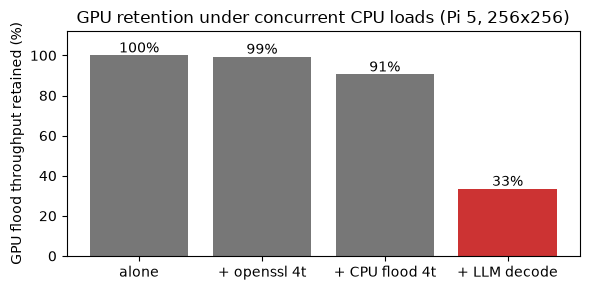

In [5]:
import matplotlib.pyplot as plt

labels = ["alone", "+ openssl 4t", "+ CPU flood 4t", "+ LLM decode"]
retained = [100,
            statistics.mean(conds["GPU + openssl 4t (compute-bound)"]) / base * 100,
            statistics.mean(conds["GPU + cpuflood 4t (memory-bound)"]) / base * 100,
            711.9 / 2127.3 * 100]
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(labels, retained, color=["#777"] * 3 + ["#c33"])
ax.set_ylabel("GPU flood throughput retained (%)")
ax.set_title("GPU retention under concurrent CPU loads (Pi 5, 256x256)")
for i, v in enumerate(retained):
    ax.text(i, v + 1.5, f"{v:.0f}%", ha="center")
ax.set_ylim(0, 112)
plt.tight_layout()
plt.savefig("gpu_retention.png", dpi=120)
plt.show()

## The device-visibility A/B

With any Vulkan device visible, llama.cpp places CPU-resident model
weights in host-pinned, write-combined GPU memory even at `-ngl 0`,
which is slow for the CPU reads that dominate decode. The archived A/B
(llama-bench tg64, r=5, cool starts):

In [6]:
A = ART / "ab_vkvisible_2026-08-10"
for tag in ("visible", "hidden"):
    line = [l for l in (A / f"{tag}.log").read_text().splitlines() if "tg64" in l][0]
    print(f"{tag:8s}", line.split("|")[-2].strip(), "t/s")
vis, hid = (float([l for l in (A / f"{t}.log").read_text().splitlines() if "tg64" in l][0]
                  .split("|")[-2].split("\u00b1")[0]) for t in ("visible", "hidden"))
print(f"\ngain from hiding the device: {hid/vis*100-100:.1f}%")

visible  9.68 ± 0.00 t/s
hidden   11.59 ± 0.00 t/s

gain from hiding the device: 19.7%


Interference tracks the CPU load's memory traffic, not its core
count. The GPU simulation coexists with any CPU-heavy workload; a
weight-streaming language model is the hardest case measured.

## Rerunning live

On the Pi:

```
OUT=/tmp/conc_bench bash pi/flood/concurrency_bench.sh
OUT=/tmp/cpu_flood_bench bash pi/flood/cpu_flood_bench.sh
OUT=/tmp/genload_bench bash pi/flood/genload_bench.sh
python3 pi/flood/analyze_conc_bench.py /tmp/conc_bench 4000
```